<a href="https://colab.research.google.com/github/Sachinkmr101/COMPARATIVE-ANALYSIS-OF-TRANSFER-LEARNING-MODELS-FOR-MEDICAL-IMAGE-CLASSIFICATION/blob/main/Updated_BrainTumorMRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Comparative Analysis of Transfer Learning Models for Medical Image Classification
### Dissertation — Chapter 4 Implementation
**Models:** VGG16 | ResNet50 | DenseNet121  
**Dataset:** Brain Tumor MRI (Kaggle)  
**Metrics:** Accuracy, Precision, Recall, F1-Score, AUC-ROC

---
> **How to use:** Runtime → Change runtime type → T4 GPU → Run All

## ✅ Step 1 — Install Dependencies & Setup

In [1]:
# Install required libraries
!pip install -q kaggle matplotlib seaborn scikit-learn tensorflow

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')
print('✅ All libraries loaded successfully!')

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries loaded successfully!


## ✅ Step 2 — Download Dataset from Kaggle

> **Setup Kaggle API (one-time):**
> 1. Go to https://www.kaggle.com → Account → Create New Token
> 2. Download `kaggle.json`
> 3. Upload it below when prompted

In [2]:
from google.colab import files

# Upload kaggle.json
print('Please upload your kaggle.json file:')
uploaded = files.upload()

# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Download Brain Tumor MRI Dataset (7023 images, 4 classes)
# Source: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
print('\nDownloading Brain Tumor MRI Dataset...')
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/dataset

print('\n✅ Dataset downloaded!')
!find /content/dataset -type d | head -20

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 147MB/s]


✅ Dataset downloaded!
/content/dataset
/content/dataset/Testing
/content/dataset/Testing/glioma
/content/dataset/Testing/notumor
/content/dataset/Testing/meningioma
/content/dataset/Testing/pituitary
/content/dataset/Training
/content/dataset/Training/glioma
/content/dataset/Training/notumor
/content/dataset/Training/meningioma
/content/dataset/Training/pituitary


## ✅ Step 3 — Configuration & Hyperparameters

In [3]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
# Paths — adjust if your dataset folder structure is different
TRAIN_DIR  = '/content/dataset/Training'
TEST_DIR   = '/content/dataset/Testing'

# Hyperparameters (matches dissertation Chapter 3 methodology)
IMG_SIZE    = (224, 224)       # All 3 models use 224x224
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-4             # Adam learning rate
PATIENCE    = 10               # Early stopping patience
DROPOUT     = 0.5
NUM_CLASSES = 4                # glioma, meningioma, notumor, pituitary

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('Configuration:')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Learning rate: {LR}')
print(f'  Early stop   : patience={PATIENCE}')
print(f'  Classes      : {CLASS_NAMES}')

Configuration:
  Image size   : (224, 224)
  Batch size   : 32
  Max epochs   : 50
  Learning rate: 0.0001
  Early stop   : patience=10
  Classes      : ['glioma', 'meningioma', 'notumor', 'pituitary']


## ✅ Step 4 — Data Preprocessing & Augmentation

In [4]:
# Training augmentation (matches dissertation Section 3.4.2)
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    shear_range       = 0.15,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    fill_mode         = 'nearest',
    validation_split  = 0.2    # 80% train, 20% val from Training folder
)

# Test / Validation — only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=42, shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

print(f'\nTrain samples      : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Test samples       : {test_gen.samples}')
print(f'Class indices      : {train_gen.class_indices}')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train samples      : 4480
Validation samples : 1120
Test samples       : 1600
Class indices      : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


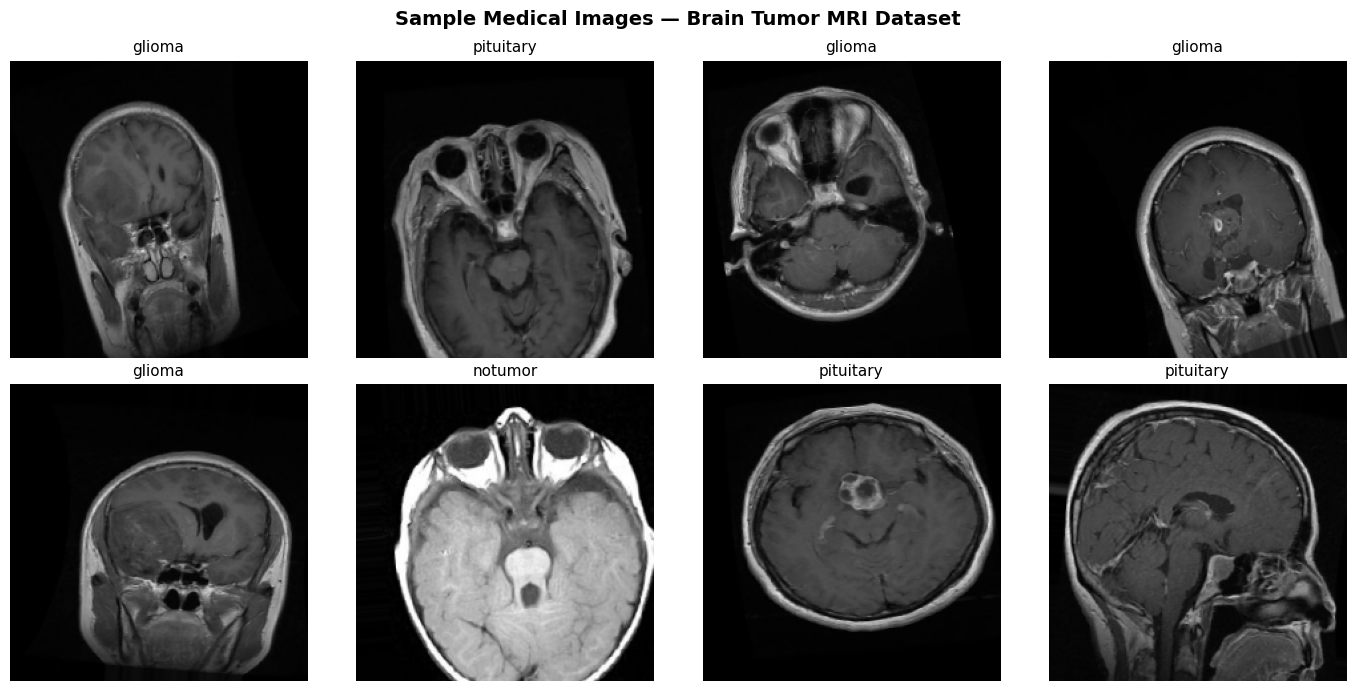

✅ Sample images visualised


In [5]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Medical Images — Brain Tumor MRI Dataset', fontsize=14, fontweight='bold')

imgs, labels = next(train_gen)
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images visualised')

## ✅ Step 5 — Build Transfer Learning Models
### Fine-tuning strategy: freeze base → train classifier → unfreeze top block → fine-tune

In [6]:
def build_model(base_name, num_classes=4, dropout=0.5, lr=1e-4):
    """
    Build a transfer learning model using fine-tuning strategy.
    Phase 1: Only classifier head is trained.
    Phase 2: Top convolutional block + head fine-tuned (low lr).
    Returns model ready for Phase 1 training.
    """
    input_shape = (224, 224, 3)

    if base_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'block5_conv1'   # Last conv block for fine-tuning
    elif base_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    elif base_name == 'DenseNet121':
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    else:
        raise ValueError(f'Unknown model: {base_name}')

    # Phase 1: Freeze entire base
    base.trainable = False

    # Classifier head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base, unfreeze_from


def unfreeze_top_block(model, base, unfreeze_from, lr=1e-5):
    """Phase 2: Unfreeze top convolutional block for fine-tuning."""
    base.trainable = True
    found = False
    for layer in base.layers:
        if layer.name == unfreeze_from:
            found = True
        layer.trainable = found

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Unfrozen from: {unfreeze_from} | Trainable layers: {trainable}')
    return model


print('✅ Model builder functions defined')

✅ Model builder functions defined


## ✅ Step 6 — Training Loop (All 3 Models)

In [7]:
def train_model(model_name):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    model, base, unfreeze_from = build_model(model_name, NUM_CLASSES, DROPOUT, LR)
    print(f'Total params: {model.count_params():,}')

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

    # ── Phase 1: Train classifier head only ──
    print('\nPhase 1: Training classifier head (base frozen)...')
    hist1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=20, callbacks=callbacks, verbose=1
    )

    # ── Phase 2: Fine-tune top convolutional block ──
    print('\nPhase 2: Fine-tuning top convolutional block...')
    model = unfreeze_top_block(model, base, unfreeze_from, lr=LR/10)

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-8, verbose=1),
        ModelCheckpoint(f'{model_name}_finetuned.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]
    hist2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=callbacks_ft, verbose=1
    )

    # Merge histories
    history = {}
    for k in hist1.history:
        history[k] = hist1.history[k] + hist2.history[k]

    return model, history


# Train all three models
models_trained  = {}
histories       = {}

for name in ['VGG16', 'ResNet50', 'DenseNet121']:
    model, history = train_model(name)
    models_trained[name]  = model
    histories[name]       = history

print('\n✅ All models trained successfully!')


  Training: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 15,111,748

Phase 1: Training classifier head (base frozen)...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.4786 - loss: 1.1953

140/140 ━━━━━━━━━━━━━━━━━━━━ 104s 617ms/step - accuracy: 0.5942 - loss: 0.9789 - val_accuracy: 0.7143 - val_loss: 1.1018 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.7331 - loss: 0.6860

140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 613ms/step - accuracy: 0.7453 - loss: 0.6624 - val_accuracy: 0.7937 - val_loss: 0.7834 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7744 - loss: 0.6037

140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 598ms/step - accuracy: 0.7833 - loss: 0.5720 - val_accuracy: 0.8339 - val_loss: 0.5460 - learning_rate: 1.0000e-04
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.7991 - loss: 0.5443

140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 615ms/step - accuracy: 0.8067 - loss: 0.5212 - val_accuracy: 0.8429 - val_loss: 0.4371 - learning_rate: 1.0000e-04
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8169 - loss: 0.4970

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 579ms/step - accuracy: 0.9085 - loss: 0.2502 - val_accuracy: 0.9277 - val_loss: 0.2014 - learning_rate: 1.0000e-04
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9055 - loss: 0.2540

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 579ms/step - accuracy: 0.9056 - loss: 0.2476 - val_accuracy: 0.9304 - val_loss: 0.2046 - learning_rate: 1.0000e-04
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 571ms/step - accuracy: 0.9067 - loss: 0.2517 - val_accuracy: 0.9241 - val_loss: 0.2138 - learning_rate: 1.0000e-04
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 572ms/step - accuracy: 0.9094 - loss: 0.2360 - val_accuracy: 0.9232 - val_loss: 0.2006 - learning_rate: 1.0000e-04
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 572ms/step - accuracy: 0.9174 - loss: 0.2248 - val_accuracy: 0.9161 - val_loss: 0.2091 - learning_rate: 1.0000e-04
Epoch 18/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9206 - loss: 0.2114

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.9183 - loss: 0.2137 - val_accuracy: 0.9312 - val_loss: 0.1927 - learning_rate: 1.0000e-04
Epoch 19/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 584ms/step - accuracy: 0.9143 - loss: 0.2209 - val_accuracy: 0.9304 - val_loss: 0.1795 - learning_rate: 1.0000e-04
Epoch 20/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9201 - loss: 0.2097

140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 587ms/step - accuracy: 0.9230 - loss: 0.2084 - val_accuracy: 0.9357 - val_loss: 0.1850 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 20.

Phase 2: Fine-tuning top convolutional block...
  Unfrozen from: conv5_block1_0_conv | Trainable layers: 7
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9250 - loss: 0.2049

140/140 ━━━━━━━━━━━━━━━━━━━━ 121s 670ms/step - accuracy: 0.9263 - loss: 0.2043 - val_accuracy: 0.9375 - val_loss: 0.1703 - learning_rate: 1.0000e-05
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.9261 - loss: 0.1993 - val_accuracy: 0.9277 - val_loss: 0.1849 - learning_rate: 1.0000e-05
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 575ms/step - accuracy: 0.9272 - loss: 0.1948 - val_accuracy: 0.9366 - val_loss: 0.1707 - learning_rate: 1.0000e-05
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 568ms/step - accuracy: 0.9217 - loss: 0.2098 - val_accuracy: 0.9339 - val_loss: 0.1855 - learning_rate: 1.0000e-05
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 579ms/step - accuracy: 0.9268 - loss: 0.2016 - val_accuracy: 0.9330 - val_loss: 0.1744 - learning_rate: 1.0000e-05
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9294 - loss: 0.1804
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 574ms/step - accur

## ✅ Step 7 — Evaluate All Models

In [8]:
from sklearn.preprocessing import label_binarize

results = {}

for name, model in models_trained.items():
    print(f'\nEvaluating {name}...')
    test_gen.reset()

    # Predictions
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = test_gen.classes

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # AUC-ROC (one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        auc_scores.append(auc(fpr, tpr))
    mean_auc = np.mean(auc_scores)

    results[name] = {
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'auc'       : mean_auc,
        'y_pred'    : y_pred,
        'y_true'    : y_true,
        'y_proba'   : y_pred_proba,
        'auc_scores': auc_scores
    }

    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {mean_auc:.4f}')

print('\n✅ Evaluation complete!')


Evaluating VGG16...
  Accuracy  : 0.9169 (91.69%)
  Precision : 0.9219
  Recall    : 0.9169
  F1-Score  : 0.9146
  AUC-ROC   : 0.9851

Evaluating ResNet50...
  Accuracy  : 0.7744 (77.44%)
  Precision : 0.7927
  Recall    : 0.7744
  F1-Score  : 0.7587
  AUC-ROC   : 0.9404

Evaluating DenseNet121...
  Accuracy  : 0.8756 (87.56%)
  Precision : 0.8813
  Recall    : 0.8756
  F1-Score  : 0.8721
  AUC-ROC   : 0.9766

✅ Evaluation complete!


## ✅ Step 8 — Results Summary Table

In [9]:
print('\n' + '='*70)
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('='*70)

for name, r in results.items():
    print(f'{name:<15} '
          f'{r["accuracy"]*100:>9.2f}% '
          f'{r["precision"]:>10.4f} '
          f'{r["recall"]:>10.4f} '
          f'{r["f1"]:>10.4f} '
          f'{r["auc"]:>10.4f}')

print('='*70)

best = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model: {best} (Accuracy: {results[best]["accuracy"]*100:.2f}%)')


Model             Accuracy  Precision     Recall   F1-Score    AUC-ROC
VGG16               91.69%     0.9219     0.9169     0.9146     0.9851
ResNet50            77.44%     0.7927     0.7744     0.7587     0.9404
DenseNet121         87.56%     0.8813     0.8756     0.8721     0.9766

Best model: VGG16 (Accuracy: 91.69%)


## ✅ Step 9 — Training & Validation Curves

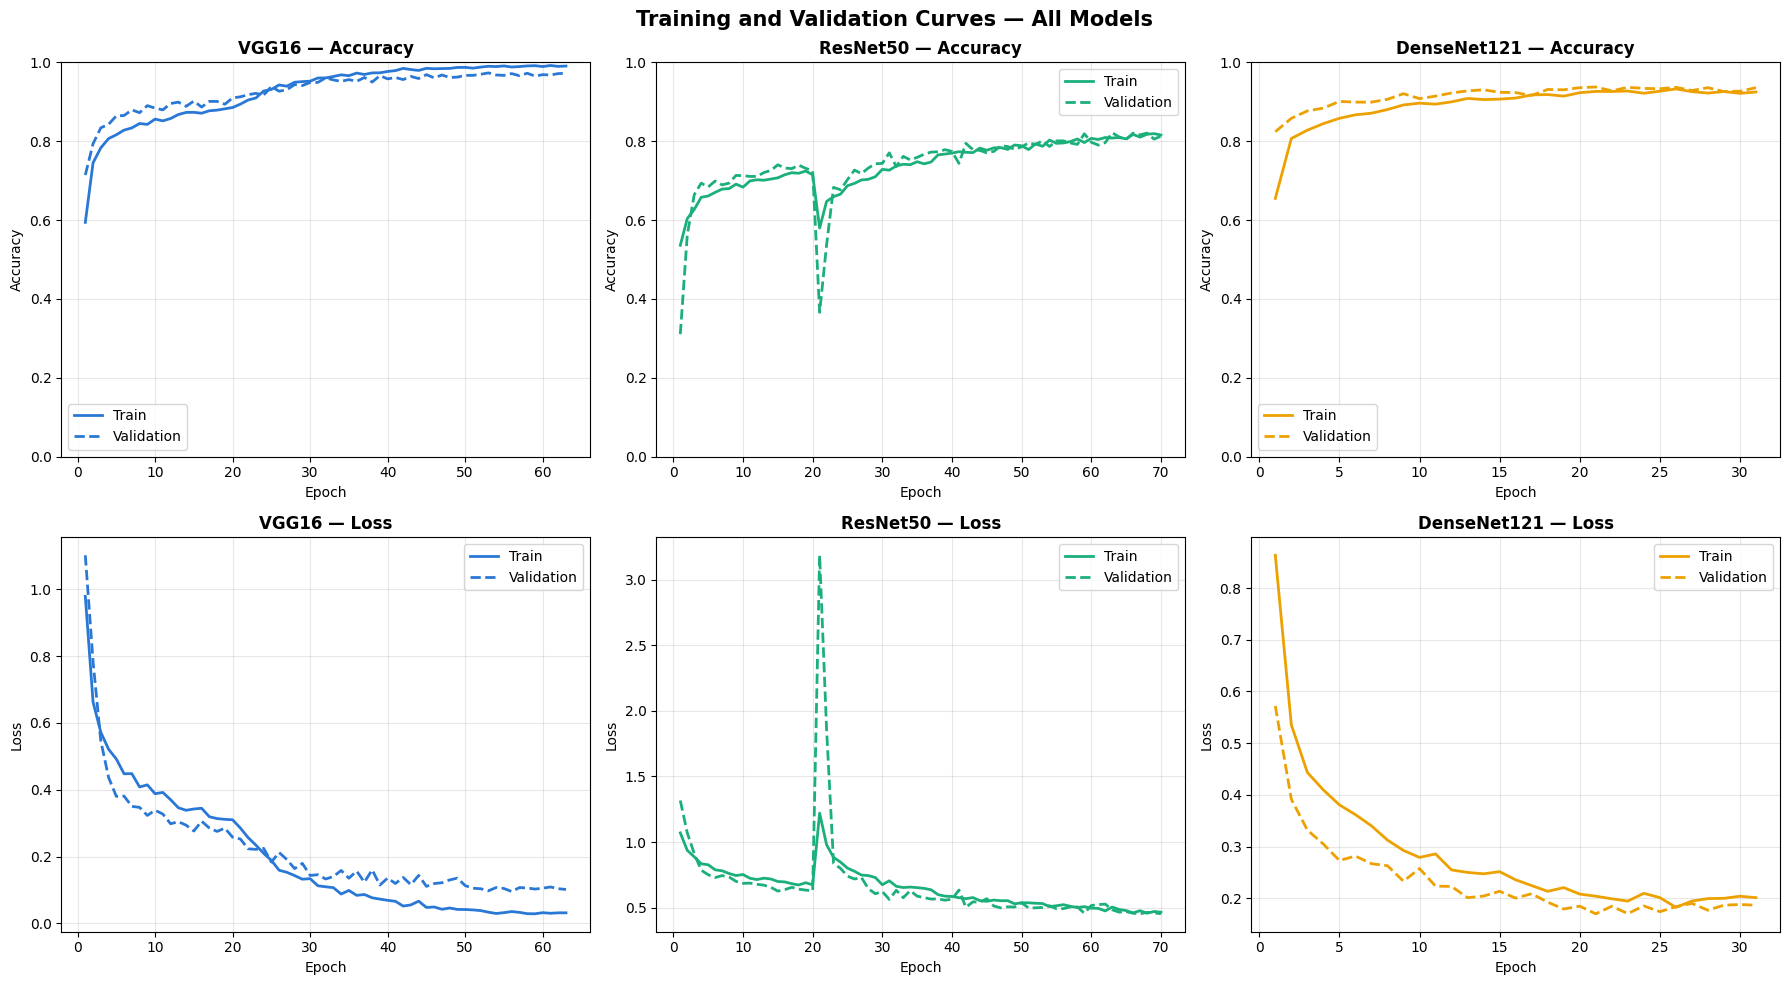

✅ Training curves saved


In [10]:
colors = {'VGG16': '#2a78d6', 'ResNet50': '#1baf7a', 'DenseNet121': '#eda100'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training and Validation Curves — All Models', fontsize=15, fontweight='bold')

for col, (name, hist) in enumerate(histories.items()):
    color = colors[name]
    epochs_ran = range(1, len(hist['accuracy']) + 1)

    # Accuracy
    ax = axes[0, col]
    ax.plot(epochs_ran, hist['accuracy'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_accuracy'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    # Loss
    ax = axes[1, col]
    ax.plot(epochs_ran, hist['loss'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_loss'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## ✅ Step 10 — Confusion Matrices

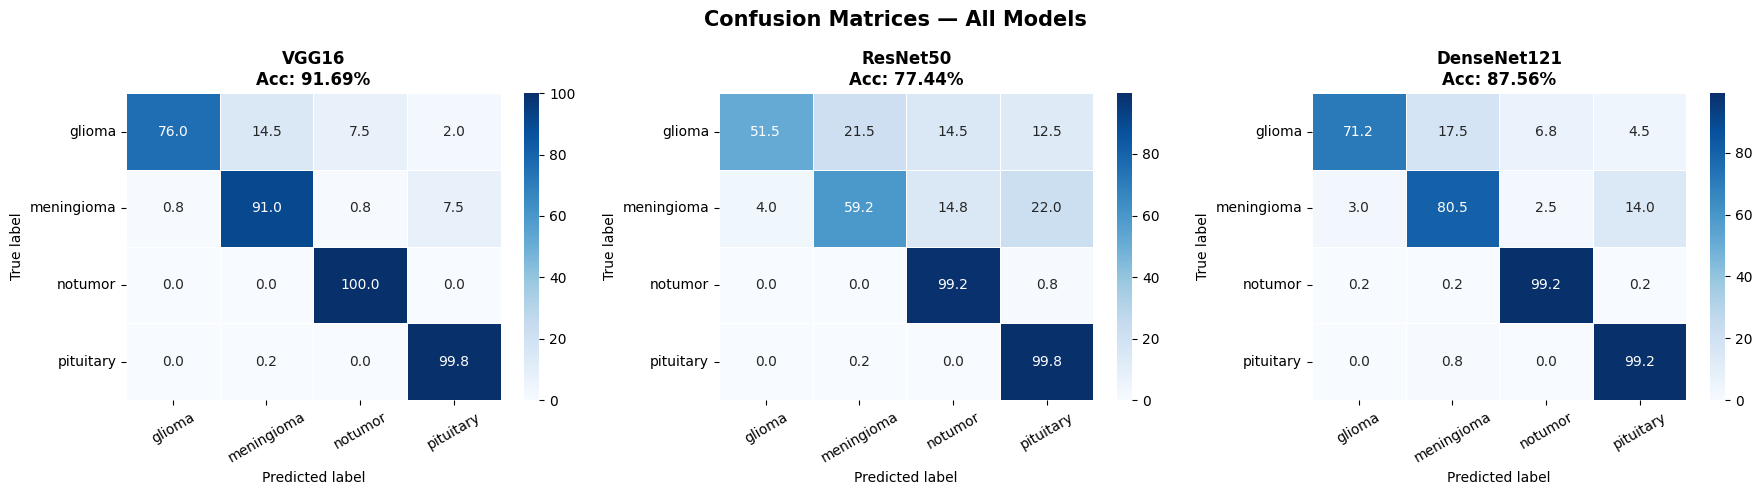

✅ Confusion matrices saved


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues', linewidths=0.5,
        annot_kws={'size': 10}
    )
    ax.set_title(f'{name}\nAcc: {r["accuracy"]*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## ✅ Step 11 — ROC Curves (AUC-ROC)

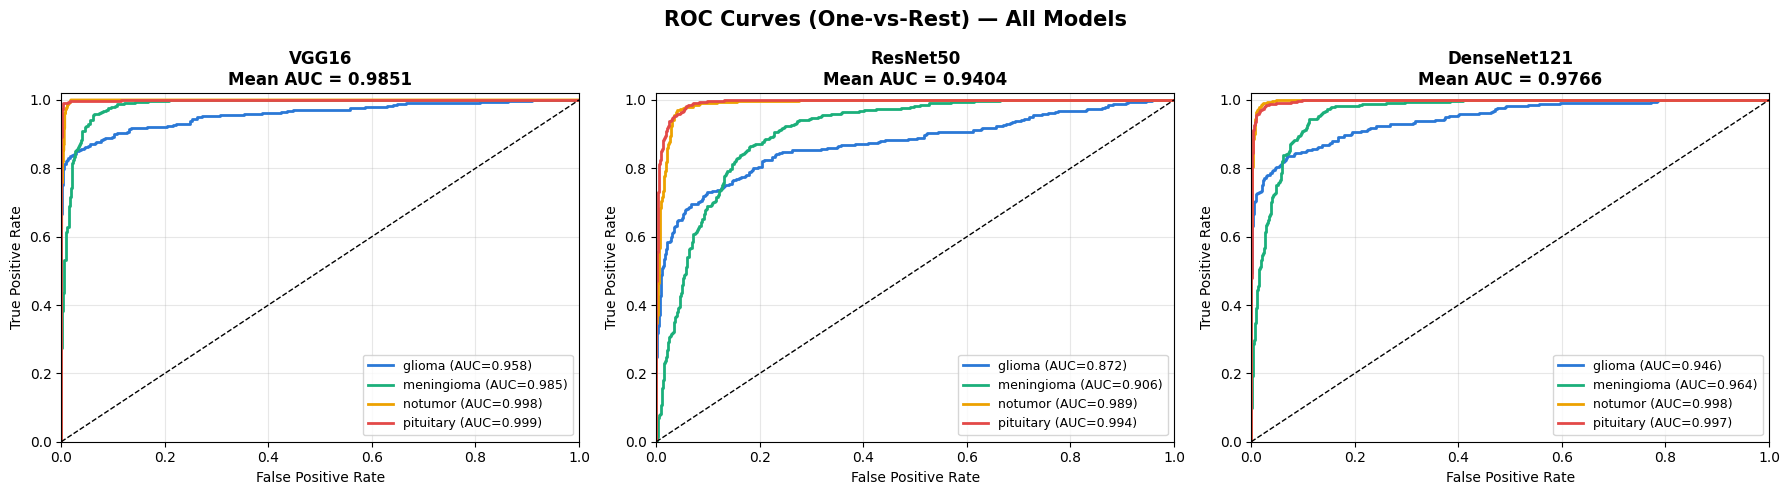

✅ ROC curves saved


In [12]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves (One-vs-Rest) — All Models', fontsize=15, fontweight='bold')

class_colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']

for ax, (name, r) in zip(axes, results.items()):
    y_true_bin = label_binarize(r['y_true'], classes=[0,1,2,3])

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], r['y_proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=class_colors[i], linewidth=2,
                label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'{name}\nMean AUC = {r["auc"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved')

## ✅ Step 12 — Bar Chart Comparison (Dissertation Figure)

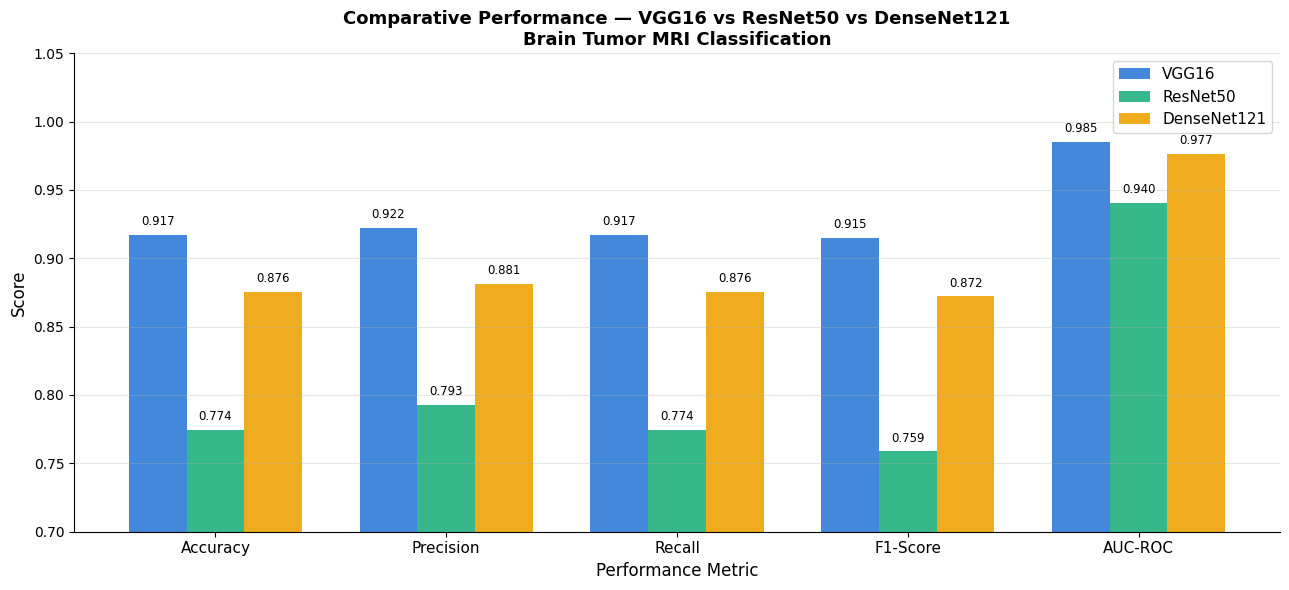

✅ Comparison bar chart saved


In [13]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = list(results.keys())
bar_colors  = ['#2a78d6', '#1baf7a', '#eda100']

data = {
    name: [
        r['accuracy'], r['precision'],
        r['recall'],   r['f1'], r['auc']
    ]
    for name, r in results.items()
}

x        = np.arange(len(metrics))
bar_w    = 0.25
fig, ax  = plt.subplots(figsize=(13, 6))

for i, (name, vals) in enumerate(data.items()):
    bars = ax.bar(x + i*bar_w, vals, bar_w,
                  label=name, color=bar_colors[i], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Performance Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparative Performance — VGG16 vs ResNet50 vs DenseNet121\nBrain Tumor MRI Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + bar_w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0.7, 1.05])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison bar chart saved')

## ✅ Step 13 — Classification Report (Per-Class)

In [14]:
for name, r in results.items():
    print(f'\n{"─"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"─"*55}')
    print(classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES, digits=4
    ))


───────────────────────────────────────────────────────
  Classification Report — VGG16
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.9902    0.7600    0.8600       400
  meningioma     0.8605    0.9100    0.8846       400
     notumor     0.9238    1.0000    0.9604       400
   pituitary     0.9130    0.9975    0.9534       400

    accuracy                         0.9169      1600
   macro avg     0.9219    0.9169    0.9146      1600
weighted avg     0.9219    0.9169    0.9146      1600


───────────────────────────────────────────────────────
  Classification Report — ResNet50
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.9279    0.5150    0.6624       400
  meningioma     0.7315    0.5925    0.6547       400
     notumor     0.7724    0.9925    0.8687       400
   pituitary     0.7389    0.9975    0.8489       400



## ✅ Step 14 — Grad-CAM Saliency Maps (Interpretability)

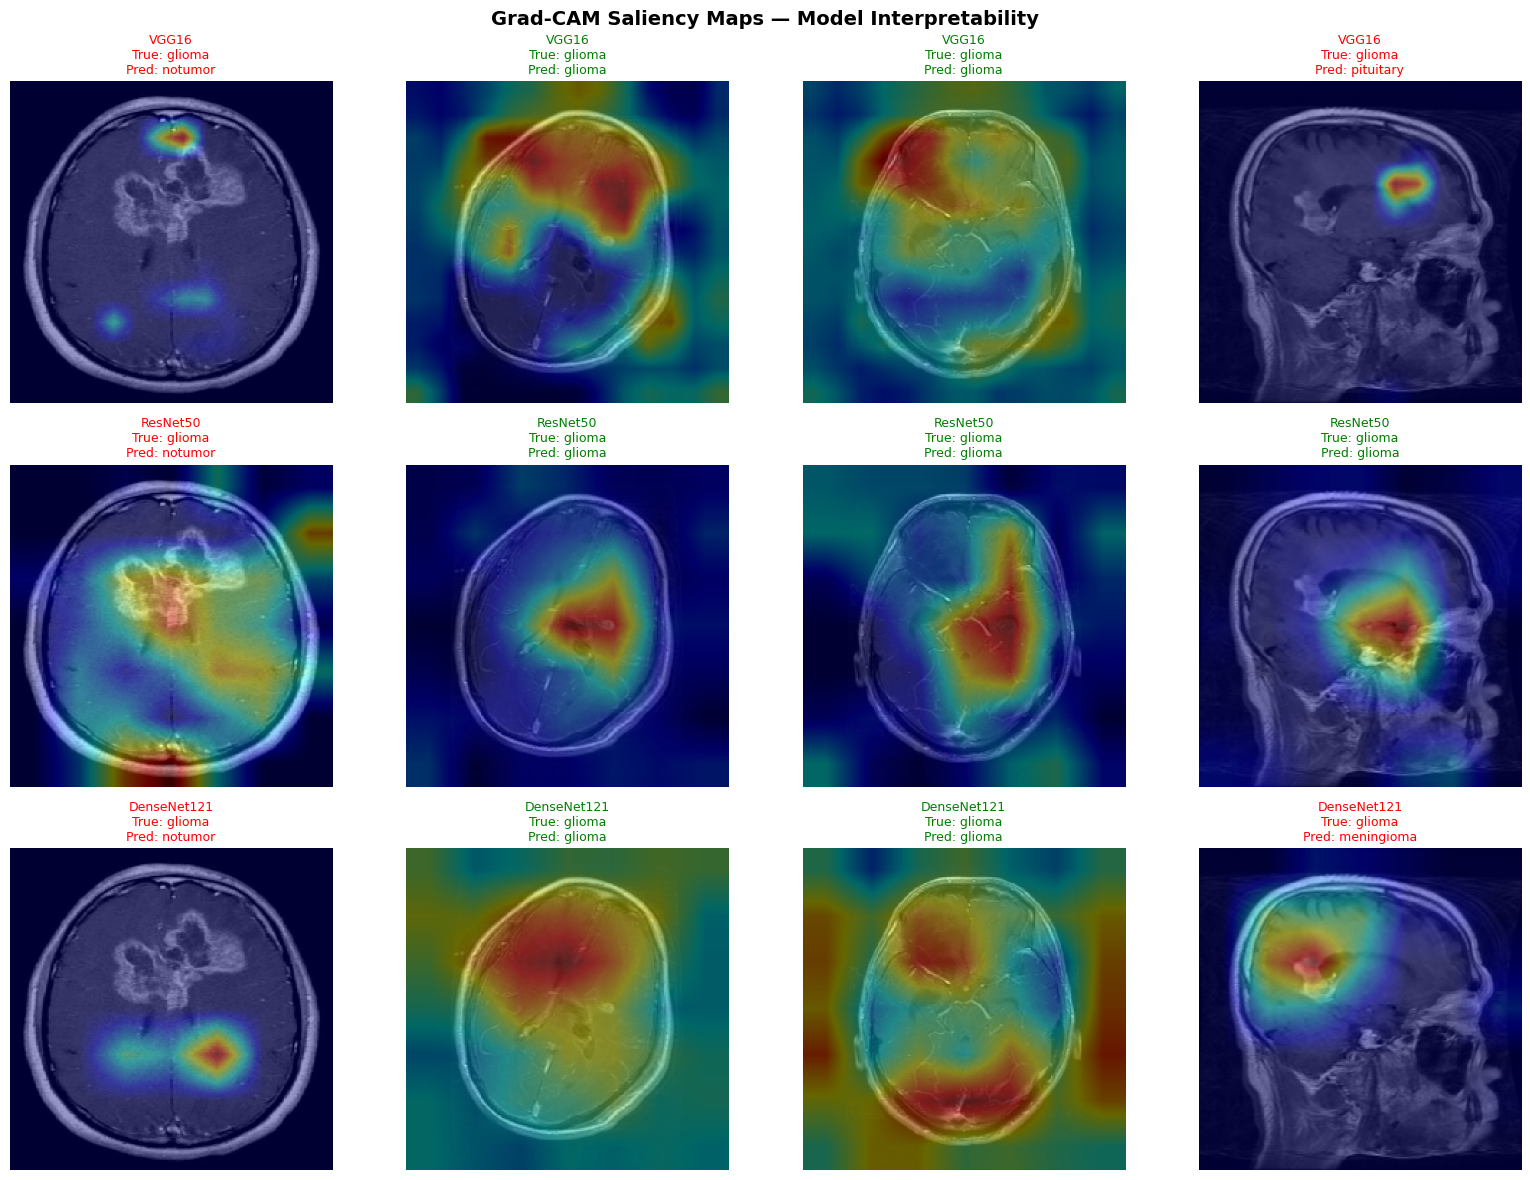

✅ Grad-CAM maps saved


In [15]:
import cv2

def get_gradcam_layer(model_name):
    return {'VGG16': 'block5_conv3',
            'ResNet50': 'conv5_block3_out',
            'DenseNet121': 'conv5_block16_concat'}[model_name]

def make_gradcam(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_heatmap(img, heatmap, alpha=0.4):
    hm = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(img * 255 * (1 - alpha) + hm * alpha)

# Get 4 test images (one per class)
test_gen.reset()
imgs_batch, labels_batch = next(test_gen)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM Saliency Maps — Model Interpretability', fontsize=14, fontweight='bold')

for row, (name, model) in enumerate(models_trained.items()):
    try:
        last_conv = get_gradcam_layer(name)
        for col in range(4):
            img = imgs_batch[col]
            img_arr = np.expand_dims(img, axis=0)
            heatmap, pred = make_gradcam(model, img_arr, last_conv)
            overlay = overlay_heatmap(img, heatmap)
            axes[row, col].imshow(overlay)
            true_cls = CLASS_NAMES[np.argmax(labels_batch[col])]
            pred_cls = CLASS_NAMES[pred]
            color = 'green' if true_cls == pred_cls else 'red'
            axes[row, col].set_title(
                f'{name}\nTrue: {true_cls}\nPred: {pred_cls}',
                fontsize=9, color=color
            )
            axes[row, col].axis('off')
    except Exception as e:
        print(f'Grad-CAM skipped for {name}: {e}')

plt.tight_layout()
plt.savefig('gradcam_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM maps saved')

## ✅ Step 15 — Download All Results

In [16]:
import zipfile, json

# Save summary JSON
summary = {
    name: {
        'accuracy' : round(float(r['accuracy']), 4),
        'precision': round(float(r['precision']), 4),
        'recall'   : round(float(r['recall']), 4),
        'f1'       : round(float(r['f1']), 4),
        'auc_roc'  : round(float(r['auc']), 4)
    }
    for name, r in results.items()
}
with open('results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Zip all outputs
output_files = [
    'sample_images.png', 'training_curves.png',
    'confusion_matrices.png', 'roc_curves.png',
    'model_comparison_bar.png', 'gradcam_maps.png',
    'results_summary.json'
]

with zipfile.ZipFile('dissertation_results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

print('\nFinal results summary:')
print(json.dumps(summary, indent=2))

# Download
files.download('dissertation_results.zip')
print('\n✅ All results downloaded!')

  Added: sample_images.png
  Added: training_curves.png
  Added: confusion_matrices.png
  Added: roc_curves.png
  Added: model_comparison_bar.png
  Added: gradcam_maps.png
  Added: results_summary.json

Final results summary:
{
  "VGG16": {
    "accuracy": 0.9169,
    "precision": 0.9219,
    "recall": 0.9169,
    "f1": 0.9146,
    "auc_roc": 0.9851
  },
  "ResNet50": {
    "accuracy": 0.7744,
    "precision": 0.7927,
    "recall": 0.7744,
    "f1": 0.7587,
    "auc_roc": 0.9404
  },
  "DenseNet121": {
    "accuracy": 0.8756,
    "precision": 0.8813,
    "recall": 0.8756,
    "f1": 0.8721,
    "auc_roc": 0.9766
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All results downloaded!
